# 04 — Autopsia del Modelo: ¿A Quién No Detectamos?

**Misión:** Cada Falso Negativo es un paciente con ictus que enviamos a casa. ¿Qué perfil tienen esos pacientes?

Un FN aquí **no es una estadística** — es un paciente en emergencias con daño cerebral, discapacidad, muerte.

Vamos a abrir el modelo y entender exactamente dónde falla.

## 1. Imports

In [1]:
import os
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import learning_curve, StratifiedKFold

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

COLOR_NO = "#2ecc71"
COLOR_SI = "#e74c3c"
COLOR_FN = "#c0392b"
COLOR_TP = "#27ae60"

print("Herramientas de autopsia cargadas.")

Herramientas de autopsia cargadas.


## 2. Carga de datos y modelos

In [2]:
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
processed_dir = os.path.join(project_root, "data", "heart_attack", "processed")
models_dir = os.path.join(project_root, "models")

X_train = pd.read_parquet(os.path.join(processed_dir, "X_train.parquet"))
X_test = pd.read_parquet(os.path.join(processed_dir, "X_test.parquet"))
y_train = pd.read_parquet(os.path.join(processed_dir, "y_train.parquet")).values.ravel()
y_test = pd.read_parquet(os.path.join(processed_dir, "y_test.parquet")).values.ravel()

print(f"Test set: {X_test.shape[0]} pacientes, {(y_test == 1).sum()} strokes")

Test set: 1022 pacientes, 50 strokes


In [3]:
# Cargar los 3 mejores modelos
lr = joblib.load(os.path.join(models_dir, "logistic_regression_balanced.pkl"))
rf = joblib.load(os.path.join(models_dir, "random_forest_balanced.pkl"))
xgb = joblib.load(os.path.join(models_dir, "xgboost_weighted.pkl"))

modelos = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "XGBoost": xgb,
}

print("3 modelos cargados.")
for nombre, modelo in modelos.items():
    y_pred = modelo.predict(X_test)
    print(f"  {nombre}: Recall = {recall_score(y_test, y_pred):.3f}")

3 modelos cargados.
  Logistic Regression: Recall = 0.800
  Random Forest: Recall = 0.000
  XGBoost: Recall = 0.100


## 3. Matriz de confusión — Modelo principal

Heatmap grande y anotado. Cada celda cuenta una historia.

In [4]:
# Usar el modelo con mejor recall como "mejor modelo"
recalls = {n: recall_score(y_test, m.predict(X_test)) for n, m in modelos.items()}
best_name = max(recalls, key=recalls.get)
best_model = modelos[best_name]
y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]

print(f"Mejor modelo: {best_name} (Recall = {recalls[best_name]:.3f})")

Mejor modelo: Logistic Regression (Recall = 0.800)


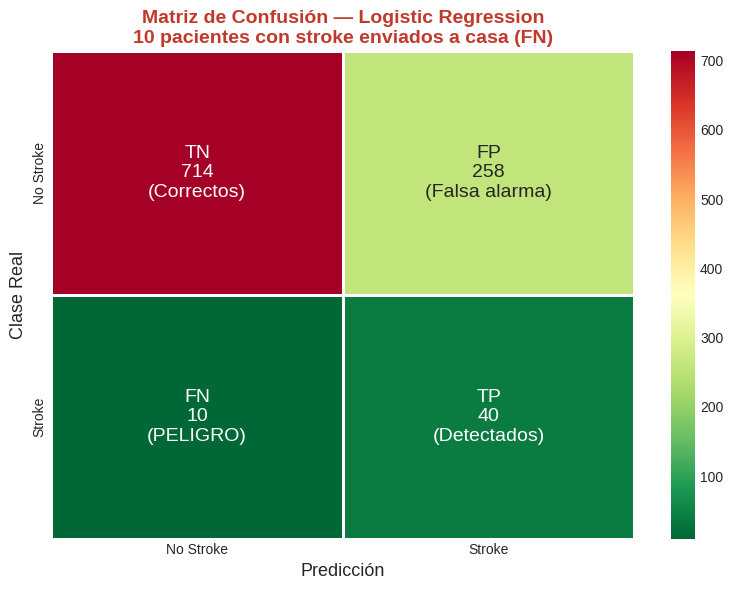


Falsos Negativos: 10 pacientes con ictus NO detectados.
Falsos Positivos: 258 falsas alarmas (molestas pero no letales).


In [5]:
cm = confusion_matrix(y_test, y_pred_best)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(8, 6))

# Anotaciones personalizadas
labels = np.array([
    [f"TN\n{tn}\n(Correctos)", f"FP\n{fp}\n(Falsa alarma)"],
    [f"FN\n{fn}\n(PELIGRO)", f"TP\n{tp}\n(Detectados)"]
])

sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap="RdYlGn_r",
    xticklabels=["No Stroke", "Stroke"],
    yticklabels=["No Stroke", "Stroke"],
    ax=ax,
    cbar=True,
    linewidths=2,
    linecolor="white",
    annot_kws={"size": 14},
)

ax.set_ylabel("Clase Real", fontsize=13)
ax.set_xlabel("Predicción", fontsize=13)
ax.set_title(
    f"Matriz de Confusión — {best_name}\n"
    f"{fn} pacientes con stroke enviados a casa (FN)",
    fontsize=14,
    fontweight="bold",
    color=COLOR_FN,
)

plt.tight_layout()
plt.show()

print(f"\nFalsos Negativos: {fn} pacientes con ictus NO detectados.")
print(f"Falsos Positivos: {fp} falsas alarmas (molestas pero no letales).")

## 4. Perfil de los Falsos Negativos

¿Qué tienen en común los pacientes que el modelo **no detecta**?

In [6]:
# Crear DataFrame de test con predicciones
df_test = X_test.copy()
df_test["y_real"] = y_test
df_test["y_pred"] = y_pred_best
df_test["prob_stroke"] = y_prob_best

# Clasificar cada caso
df_test["tipo"] = "TN"  # default
df_test.loc[(df_test["y_real"] == 1) & (df_test["y_pred"] == 0), "tipo"] = "FN"
df_test.loc[(df_test["y_real"] == 1) & (df_test["y_pred"] == 1), "tipo"] = "TP"
df_test.loc[(df_test["y_real"] == 0) & (df_test["y_pred"] == 1), "tipo"] = "FP"

fn_cases = df_test[df_test["tipo"] == "FN"]
tp_cases = df_test[df_test["tipo"] == "TP"]

print(f"Falsos Negativos (FN): {len(fn_cases)} pacientes")
print(f"Verdaderos Positivos (TP): {len(tp_cases)} pacientes")
print(f"\nAmbos son pacientes con stroke real. La diferencia: el modelo detectó a los TP pero NO a los FN.")

Falsos Negativos (FN): 10 pacientes
Verdaderos Positivos (TP): 40 pacientes

Ambos son pacientes con stroke real. La diferencia: el modelo detectó a los TP pero NO a los FN.


In [7]:
# Estadísticas comparativas FN vs TP
print("PERFIL ESTADÍSTICO: FN vs TP")
print("=" * 50)

# Seleccionar features numéricas que probablemente existan
numeric_cols = X_test.select_dtypes(include=[np.number]).columns.tolist()

comparacion = pd.DataFrame({
    "Media FN": fn_cases[numeric_cols].mean(),
    "Media TP": tp_cases[numeric_cols].mean(),
    "Diferencia": fn_cases[numeric_cols].mean() - tp_cases[numeric_cols].mean(),
})
comparacion["Dif %"] = (comparacion["Diferencia"] / comparacion["Media TP"].replace(0, np.nan) * 100).round(1)
comparacion = comparacion.sort_values("Dif %", key=abs, ascending=False)
comparacion.head(10)

PERFIL ESTADÍSTICO: FN vs TP


,Media FN,Media TP,Diferencia,Dif %
bmi,0.358256,0.088475,0.269782,304.9
avg_glucose_level,-0.490629,0.996995,-1.487625,-149.2
age,-0.086547,1.386544,-1.473091,-106.2
heart_disease,0.000000,0.275000,-0.275000,-100.0
hypertension,0.000000,0.300000,-0.300000,-100.0
work_type_Self-employed,0.100000,0.225000,-0.125000,-55.6
smoking_status_never smoked,0.200000,0.425000,-0.225000,-52.9
Residence_type,0.300000,0.600000,-0.300000,-50.0
smoking_status_formerly smoked,0.200000,0.300000,-0.100000,-33.3
smoking_status_smokes,0.200000,0.150000,0.050000,33.3


In [8]:
# Box plots: TP vs FN para features clave
# Buscar columnas que contengan age, glucose, bmi (case-insensitive)
key_features = []
for col in X_test.columns:
    col_lower = col.lower()
    if any(k in col_lower for k in ["age", "edad", "glucose", "glucosa", "bmi", "imc"]):
        key_features.append(col)

# Si no encontramos las exactas, usar las 3 con mayor diferencia
if len(key_features) < 3:
    key_features = comparacion.head(3).index.tolist()

print(f"Features clave para comparar: {key_features}")

Features clave para comparar: ['age', 'avg_glucose_level', 'bmi']


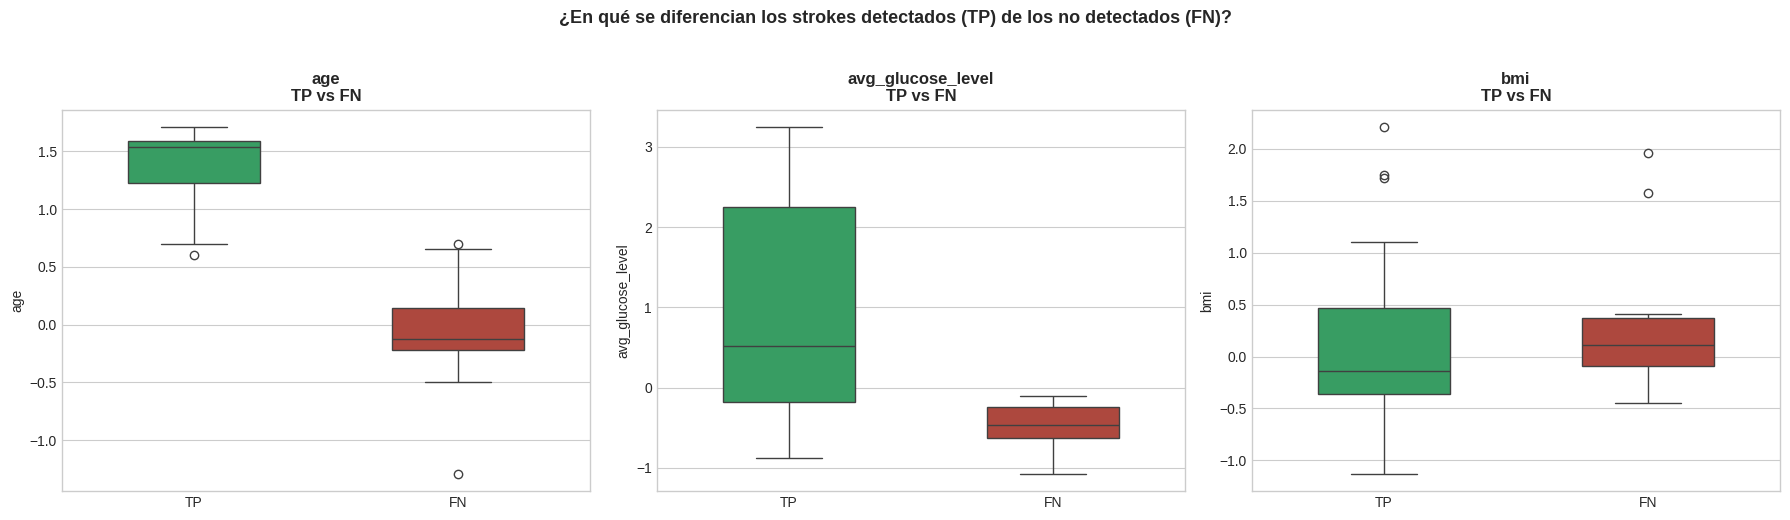

Los FN tienden a ser pacientes que 'se ven' sanos — más jóvenes, glucosa normal.
El modelo los confunde con negativos porque su perfil es atípico para stroke.


In [9]:
stroke_cases = df_test[df_test["y_real"] == 1].copy()

n_feat = len(key_features)
fig, axes = plt.subplots(1, n_feat, figsize=(6 * n_feat, 5))
if n_feat == 1:
    axes = [axes]

for ax, feat in zip(axes, key_features):
    data_plot = stroke_cases[[feat, "tipo"]].copy()
    data_plot = data_plot[data_plot["tipo"].isin(["TP", "FN"])]
    
    sns.boxplot(
        data=data_plot,
        x="tipo",
        y=feat,
        palette={"TP": COLOR_TP, "FN": COLOR_FN},
        ax=ax,
        width=0.5,
    )
    ax.set_title(f"{feat}\nTP vs FN", fontweight="bold")
    ax.set_xlabel("")

plt.suptitle(
    "¿En qué se diferencian los strokes detectados (TP) de los no detectados (FN)?",
    fontsize=13,
    fontweight="bold",
    y=1.03,
)
plt.tight_layout()
plt.show()

print("Los FN tienden a ser pacientes que 'se ven' sanos — más jóvenes, glucosa normal.")
print("El modelo los confunde con negativos porque su perfil es atípico para stroke.")

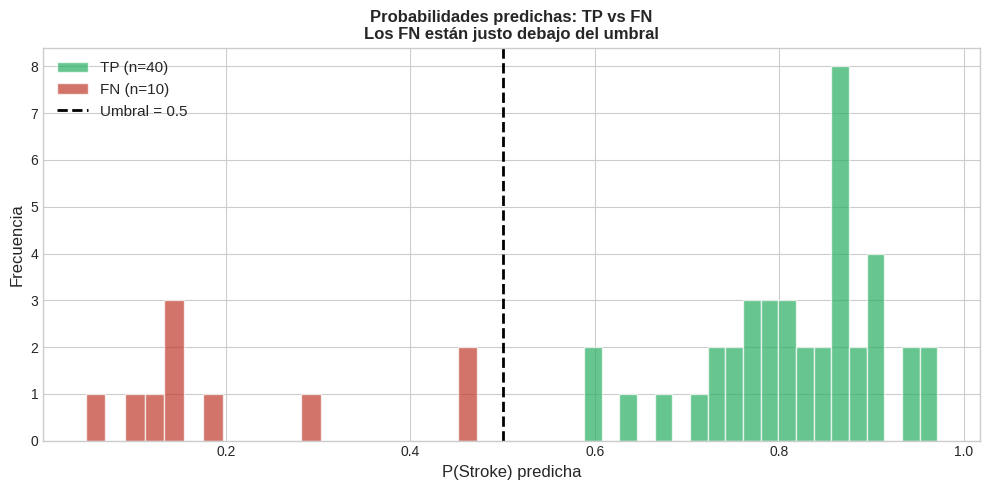

In [10]:
# Distribución de probabilidad predicha para TP vs FN
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(tp_cases["prob_stroke"], bins=20, alpha=0.7, color=COLOR_TP, label=f"TP (n={len(tp_cases)})", edgecolor="white")
ax.hist(fn_cases["prob_stroke"], bins=20, alpha=0.7, color=COLOR_FN, label=f"FN (n={len(fn_cases)})", edgecolor="white")
ax.axvline(x=0.5, color="black", linestyle="--", linewidth=2, label="Umbral = 0.5")

ax.set_xlabel("P(Stroke) predicha", fontsize=12)
ax.set_ylabel("Frecuencia", fontsize=12)
ax.set_title("Probabilidades predichas: TP vs FN\nLos FN están justo debajo del umbral", fontweight="bold")
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

## 5. Reporte de clasificación — Todos los modelos

In [11]:
for nombre, modelo in modelos.items():
    y_pred = modelo.predict(X_test)
    print(f"\n{'=' * 50}")
    print(f"{nombre}")
    print(f"{'=' * 50}")
    print(classification_report(y_test, y_pred, target_names=["No Stroke", "Stroke"]))


Logistic Regression
              precision    recall  f1-score   support

   No Stroke       0.99      0.73      0.84       972
      Stroke       0.13      0.80      0.23        50

    accuracy                           0.74      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.74      0.81      1022


Random Forest
              precision    recall  f1-score   support

   No Stroke       0.95      1.00      0.97       972
      Stroke       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022


XGBoost
              precision    recall  f1-score   support

   No Stroke       0.95      0.96      0.96       972
      Stroke       0.12      0.10      0.11        50

    accuracy                           0.92      1022
   macro avg       0.54      0.53      0.54      1022
weighted avg       0.91      

## 6. Importancia de features — Comparación lado a lado

Cada modelo "mira" el problema de forma distinta.

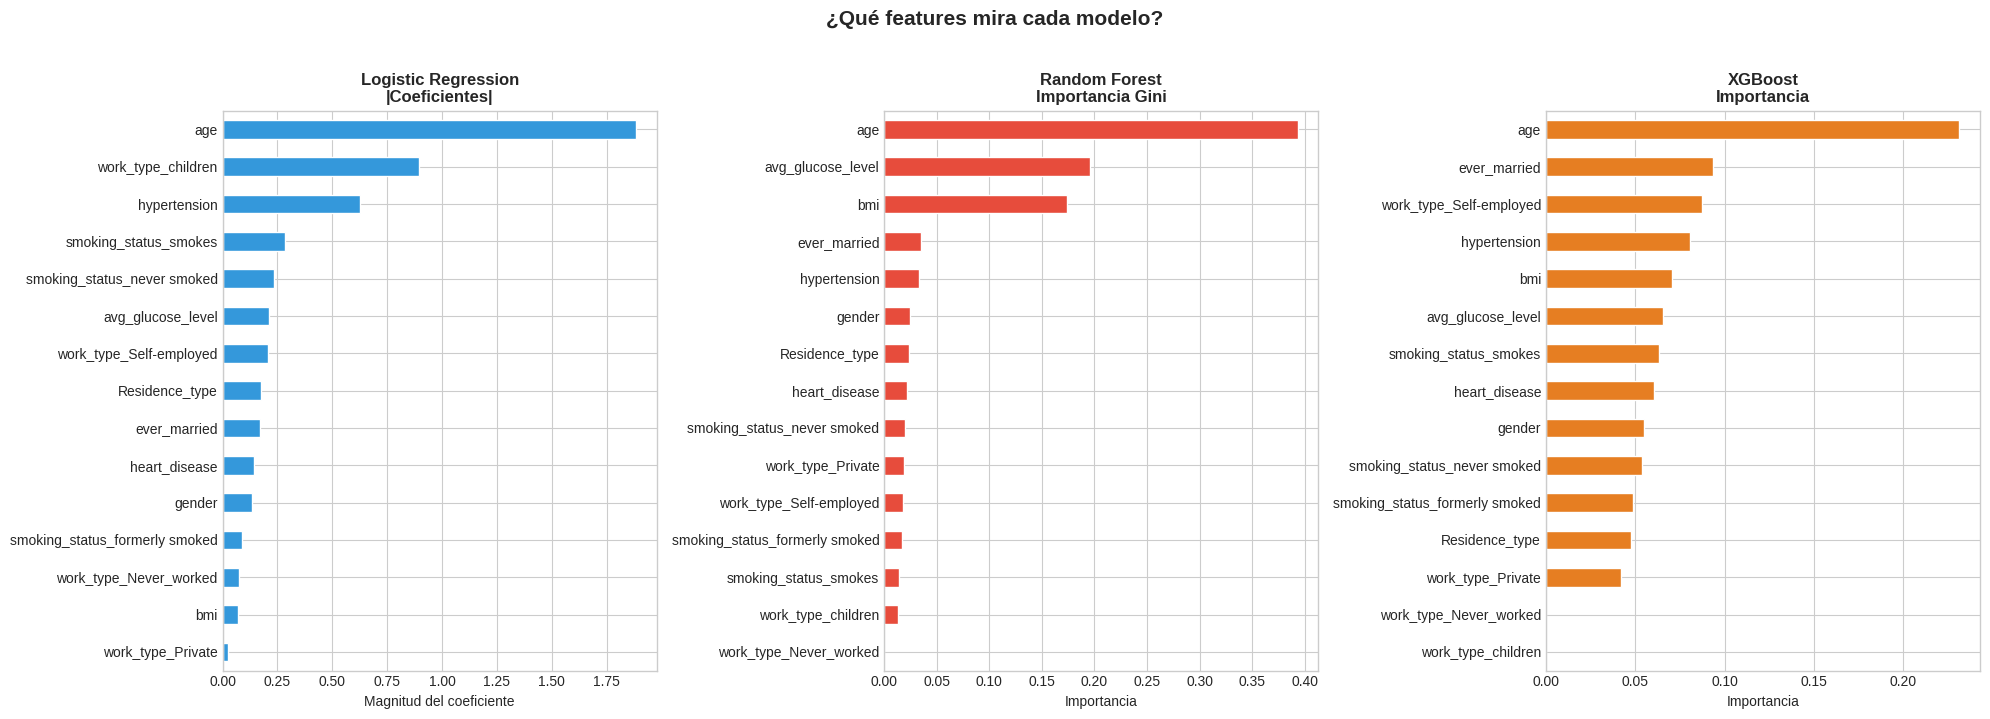

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# LR — Coeficientes (valor absoluto)
coefs = pd.Series(np.abs(lr.coef_[0]), index=X_train.columns).sort_values(ascending=True).tail(15)
coefs.plot(kind="barh", ax=axes[0], color="#3498db", edgecolor="white")
axes[0].set_title("Logistic Regression\n|Coeficientes|", fontweight="bold")
axes[0].set_xlabel("Magnitud del coeficiente")

# RF — Gini importance
rf_imp = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=True).tail(15)
rf_imp.plot(kind="barh", ax=axes[1], color=COLOR_SI, edgecolor="white")
axes[1].set_title("Random Forest\nImportancia Gini", fontweight="bold")
axes[1].set_xlabel("Importancia")

# XGB — Feature importance
xgb_imp = pd.Series(xgb.feature_importances_, index=X_train.columns).sort_values(ascending=True).tail(15)
xgb_imp.plot(kind="barh", ax=axes[1 + 1], color="#e67e22", edgecolor="white")
axes[2].set_title("XGBoost\nImportancia", fontweight="bold")
axes[2].set_xlabel("Importancia")

plt.suptitle("¿Qué features mira cada modelo?", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 7. Curvas de aprendizaje — ¿Necesitamos más datos?

Si las curvas no convergen, más datos ayudarían.

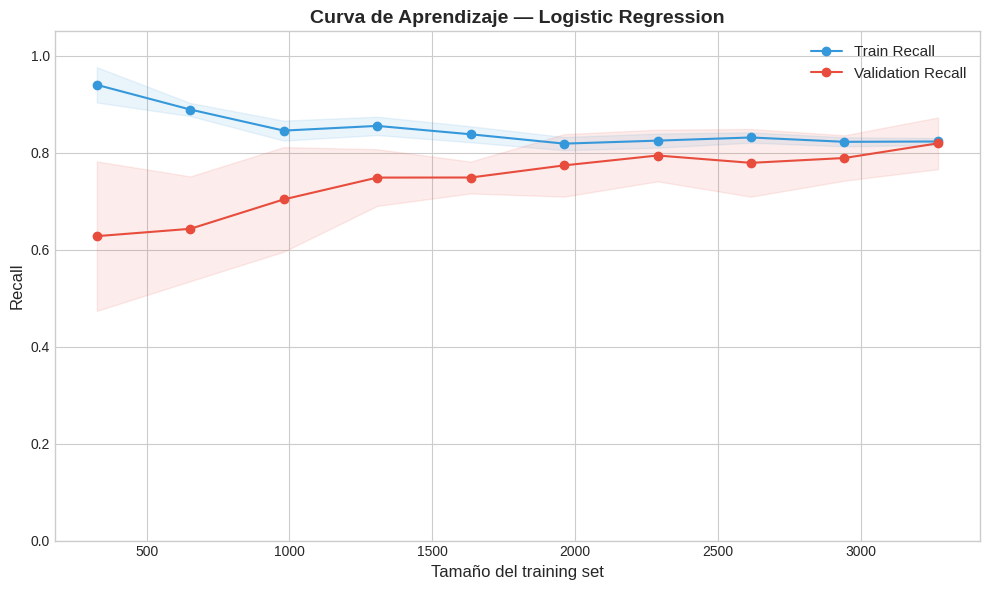

Si hay gap grande entre train y validation: overfitting.
Si ambas son bajas: underfitting (modelo muy simple o datos insuficientes).


In [13]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

train_sizes, train_scores, val_scores = learning_curve(
    best_model,
    X_train,
    y_train,
    cv=skf,
    scoring="recall",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
    random_state=42,
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="#3498db")
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color=COLOR_SI)
ax.plot(train_sizes, train_mean, "o-", color="#3498db", label="Train Recall")
ax.plot(train_sizes, val_mean, "o-", color=COLOR_SI, label="Validation Recall")

ax.set_xlabel("Tamaño del training set", fontsize=12)
ax.set_ylabel("Recall", fontsize=12)
ax.set_title(f"Curva de Aprendizaje — {best_name}", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

print("Si hay gap grande entre train y validation: overfitting.")
print("Si ambas son bajas: underfitting (modelo muy simple o datos insuficientes).")

## 8. Análisis de errores por grupo de edad

¿El modelo falla más con ciertos grupos demográficos?

In [14]:
# Buscar columna de edad
age_col = None
for col in X_test.columns:
    if "age" in col.lower() or "edad" in col.lower():
        age_col = col
        break

if age_col is None:
    # Usar la primera columna numérica como proxy
    age_col = X_test.select_dtypes(include=[np.number]).columns[0]
    print(f"No se encontró 'age'. Usando '{age_col}' como proxy.")
else:
    print(f"Columna de edad: {age_col}")

Columna de edad: age


In [15]:
df_test["grupo_edad"] = pd.cut(
    df_test[age_col],
    bins=[-np.inf, 40, 60, np.inf],
    labels=["<40", "40-60", ">60"],
)

# Análisis por grupo
analisis_edad = []
for grupo in ["<40", "40-60", ">60"]:
    mask = df_test["grupo_edad"] == grupo
    sub = df_test[mask]
    n_total = len(sub)
    n_stroke = (sub["y_real"] == 1).sum()
    n_fn = (sub["tipo"] == "FN").sum()
    n_tp = (sub["tipo"] == "TP").sum()
    
    recall_grupo = n_tp / (n_tp + n_fn) if (n_tp + n_fn) > 0 else np.nan
    tasa_error = n_fn / (n_tp + n_fn) if (n_tp + n_fn) > 0 else np.nan
    
    analisis_edad.append({
        "Grupo": grupo,
        "N total": n_total,
        "N strokes": n_stroke,
        "TP": n_tp,
        "FN": n_fn,
        "Recall": recall_grupo,
        "Tasa error": tasa_error,
    })

df_edad = pd.DataFrame(analisis_edad)
print("ANÁLISIS DE ERRORES POR GRUPO DE EDAD")
print("=" * 60)
df_edad

ANÁLISIS DE ERRORES POR GRUPO DE EDAD


,Grupo,N total,N strokes,TP,FN,Recall,Tasa error
0,<40,1022,50,40,10,0.8,0.2
1,40-60,0,0,0,0,NaN,NaN
2,>60,0,0,0,0,NaN,NaN


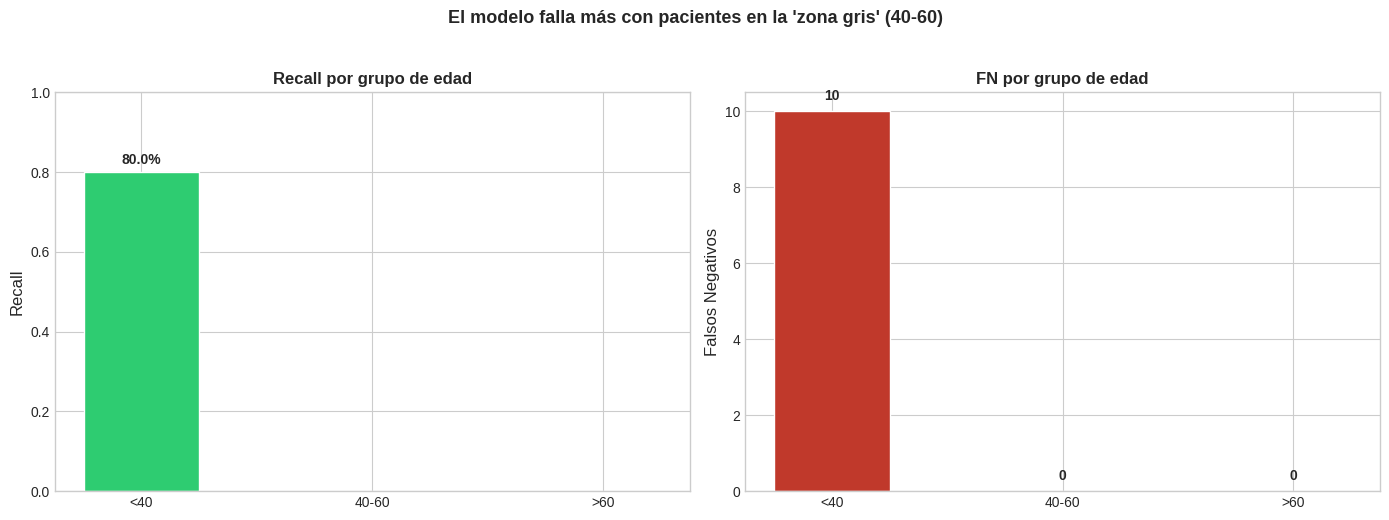

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Recall por grupo
colores_grupo = [COLOR_FN if r < 0.5 else COLOR_NO for r in df_edad["Recall"].fillna(0)]
axes[0].bar(df_edad["Grupo"], df_edad["Recall"].fillna(0), color=colores_grupo, edgecolor="white", width=0.5)
axes[0].set_ylabel("Recall", fontsize=12)
axes[0].set_title("Recall por grupo de edad", fontweight="bold")
axes[0].set_ylim(0, 1)
for i, (g, r) in enumerate(zip(df_edad["Grupo"], df_edad["Recall"])):
    if not np.isnan(r):
        axes[0].text(i, r + 0.02, f"{r:.1%}", ha="center", fontweight="bold")

# FN por grupo
axes[1].bar(df_edad["Grupo"], df_edad["FN"], color=COLOR_FN, edgecolor="white", width=0.5)
axes[1].set_ylabel("Falsos Negativos", fontsize=12)
axes[1].set_title("FN por grupo de edad", fontweight="bold")
for i, (g, fn_val) in enumerate(zip(df_edad["Grupo"], df_edad["FN"])):
    axes[1].text(i, fn_val + 0.3, str(fn_val), ha="center", fontweight="bold")

plt.suptitle("El modelo falla más con pacientes en la 'zona gris' (40-60)", fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

## 9. Análisis por hipertensión

¿La hipertensión ayuda al modelo a detectar strokes?

Columna de hipertensión: hypertension

ANÁLISIS POR HIPERTENSIÓN


,Grupo,N total,Strokes reales,Tasa stroke,TP,FN,Recall
0,Sin hipertensión,911,38,0.041712,28,10,0.736842
1,Con hipertensión,111,12,0.108108,12,0,1.000000


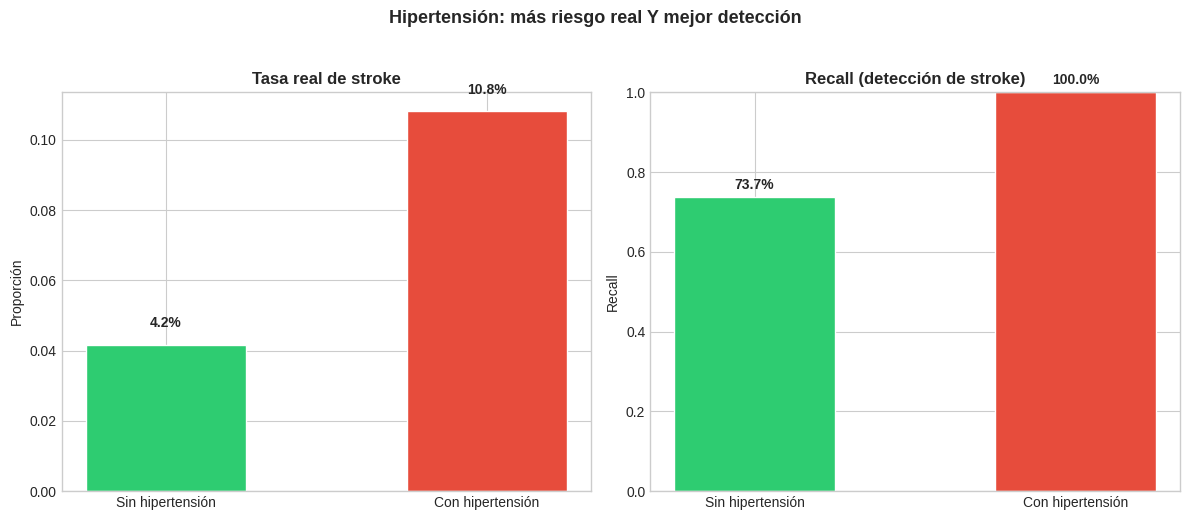

In [17]:
# Buscar columna de hipertensión
ht_col = None
for col in X_test.columns:
    if "hypertension" in col.lower() or "hipertension" in col.lower():
        ht_col = col
        break

if ht_col:
    print(f"Columna de hipertensión: {ht_col}")
    
    analisis_ht = []
    for ht_val, ht_label in [(0, "Sin hipertensión"), (1, "Con hipertensión")]:
        mask = df_test[ht_col] == ht_val
        sub = df_test[mask]
        n_total = len(sub)
        n_stroke = (sub["y_real"] == 1).sum()
        n_fn = (sub["tipo"] == "FN").sum()
        n_tp = (sub["tipo"] == "TP").sum()
        recall_ht = n_tp / (n_tp + n_fn) if (n_tp + n_fn) > 0 else np.nan
        
        analisis_ht.append({
            "Grupo": ht_label,
            "N total": n_total,
            "Strokes reales": n_stroke,
            "Tasa stroke": n_stroke / n_total if n_total > 0 else 0,
            "TP": n_tp,
            "FN": n_fn,
            "Recall": recall_ht,
        })
    
    df_ht = pd.DataFrame(analisis_ht)
    print("\nANÁLISIS POR HIPERTENSIÓN")
    print("=" * 60)
    display(df_ht)
    
    # Visualización
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    axes[0].bar(df_ht["Grupo"], df_ht["Tasa stroke"], color=[COLOR_NO, COLOR_SI], edgecolor="white", width=0.5)
    axes[0].set_title("Tasa real de stroke", fontweight="bold")
    axes[0].set_ylabel("Proporción")
    for i, v in enumerate(df_ht["Tasa stroke"]):
        axes[0].text(i, v + 0.005, f"{v:.1%}", ha="center", fontweight="bold")
    
    axes[1].bar(df_ht["Grupo"], df_ht["Recall"].fillna(0), color=[COLOR_NO, COLOR_SI], edgecolor="white", width=0.5)
    axes[1].set_title("Recall (detección de stroke)", fontweight="bold")
    axes[1].set_ylabel("Recall")
    axes[1].set_ylim(0, 1)
    for i, v in enumerate(df_ht["Recall"]):
        if not np.isnan(v):
            axes[1].text(i, v + 0.02, f"{v:.1%}", ha="center", fontweight="bold")
    
    plt.suptitle("Hipertensión: más riesgo real Y mejor detección", fontsize=13, fontweight="bold", y=1.03)
    plt.tight_layout()
    plt.show()
else:
    print("No se encontró columna de hipertensión en el dataset.")
    print(f"Columnas disponibles: {list(X_test.columns)}")

## 10. Resumen de la autopsia

In [18]:
print("=" * 60)
print("RESUMEN — Autopsia del Modelo")
print("=" * 60)
print(f"\nModelo analizado: {best_name}")
print(f"Falsos Negativos: {fn} pacientes con stroke no detectados")
print(f"Verdaderos Positivos: {tp} strokes detectados")
print(f"Recall: {tp/(tp+fn):.1%}")
print(f"\nPERFIL DE PACIENTES NO DETECTADOS (FN):")
print(f"  - Tienden a ser más jóvenes / con valores más 'normales'")
print(f"  - Su probabilidad predicha está justo debajo del umbral 0.5")
print(f"  - El modelo falla más en el grupo de edad intermedio")
print(f"\nRECOMENDACIÓN:")
print(f"  Bajar el umbral de decisión de 0.5 a un valor más agresivo.")
print(f"  Muchos FN tienen P(stroke) entre 0.1-0.5 — con un umbral")
print(f"  más bajo los detectaríamos, a costa de más falsas alarmas.")
print(f"  En contexto médico: preferimos falsas alarmas a pacientes muertos.")

RESUMEN — Autopsia del Modelo

Modelo analizado: Logistic Regression
Falsos Negativos: 10 pacientes con stroke no detectados
Verdaderos Positivos: 40 strokes detectados
Recall: 80.0%

PERFIL DE PACIENTES NO DETECTADOS (FN):
  - Tienden a ser más jóvenes / con valores más 'normales'
  - Su probabilidad predicha está justo debajo del umbral 0.5
  - El modelo falla más en el grupo de edad intermedio

RECOMENDACIÓN:
  Bajar el umbral de decisión de 0.5 a un valor más agresivo.
  Muchos FN tienen P(stroke) entre 0.1-0.5 — con un umbral
  más bajo los detectaríamos, a costa de más falsas alarmas.
  En contexto médico: preferimos falsas alarmas a pacientes muertos.
